# Individual homework project 1

In [3]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
import os

In [6]:
# Import data
#Checking the documents location
#print(os.getcwd())
#print(os.listdir())

customers = pd.read_csv("customers.csv")
transactions = pd.read_csv("transactions.csv")
sessions = pd.read_csv("web_sessions.csv")
campaigns = pd.read_csv("marketing_campaigns.csv")

In [13]:
#Exploring the datasets
print(f'"Customers:" {customers.columns}')
print(f'"Transactions:" {transactions.columns}')
print(f'"Sessions:" {sessions.columns}')
print(f'"Campaigns:" {campaigns.columns}')

"Customers:" Index(['customer_id', 'age', 'gender', 'country', 'acquisition_channel',
       'signup_date'],
      dtype='object')
"Transactions:" Index(['transaction_id', 'customer_id', 'product_category', 'purchase_value',
       'discount_used', 'purchase_date'],
      dtype='object')
"Sessions:" Index(['session_id', 'customer_id', 'pages_viewed', 'time_on_site',
       'device_type', 'traffic_source', 'session_date', 'converted'],
      dtype='object')
"Campaigns:" Index(['campaign_id', 'channel', 'spend', 'impressions', 'clicks',
       'conversions', 'date'],
      dtype='object')


### Specific questions

Q1. What is the average purchase value for customers from Spain?

Having checked the columns on each dataset, it was noticed the costumer dataset itself doesn't contain all the information needed to answer this question. A merge of two different dataset would be needed, the two datasets would be customers and transactions. 
These two dataset would join on the attribute customer_Id.

In [17]:
# Insert code here
#Investigating more about the customers dataframe

#Dataset 1
customers.head()

,customer_id,age,gender,country,acquisition_channel,signup_date
0,1,56.0,Other,Germany,referral,2019-07-21
1,2,38.0,Other,Netherlands,email,2022-03-04
2,3,28.0,Other,Australia,referral,2024-05-21
3,4,19.0,Female,Australia,paid_search,2022-06-28
4,5,38.0,Female,Australia,referral,2024-07-17


In [15]:
customers.shape

(10000, 6)

In [16]:
customers.isnull().sum()

customer_id              0
age                    807
gender                   0
country                  0
acquisition_channel      0
signup_date              0
dtype: int64

As shown above this dataset has missing values, hovewer for this specific question this missing wouldn't have any influence, so they would be lelft as they are for now.

In [19]:
#Dataset 2
transactions.head()

,transaction_id,customer_id,product_category,purchase_value,discount_used,purchase_date
0,1,8141,home,74.32,0,2023-09-05
1,2,1297,fashion,17.51,0,2019-08-07
2,3,7930,toys,39.96,1,2020-02-07
3,4,2426,electronics,43.79,0,2020-10-02
4,5,6614,fashion,187.01,0,2023-09-15


In [21]:
transactions.shape

(45000, 6)

In [22]:
transactions.isnull().sum()

transaction_id      0
customer_id         0
product_category    0
purchase_value      0
discount_used       0
purchase_date       0
dtype: int64

In [24]:
#Merged dataset

df1_merged = pd.merge(transactions, customers, on = "customer_id", how = "left")
df1_merged.head()

,transaction_id,customer_id,product_category,purchase_value,discount_used,purchase_date,age,gender,country,acquisition_channel,signup_date
0,1,8141,home,74.32,0,2023-09-05,39.0,Male,UK,social,2021-04-13
1,2,1297,fashion,17.51,0,2019-08-07,43.0,Female,Spain,email,2024-03-10
2,3,7930,toys,39.96,1,2020-02-07,19.0,Male,Netherlands,referral,2022-11-28
3,4,2426,electronics,43.79,0,2020-10-02,67.0,Female,Australia,referral,2023-09-14
4,5,6614,fashion,187.01,0,2023-09-15,50.0,Other,Germany,paid_search,2021-10-20


In [25]:
df1_merged.shape

(45000, 11)

In [71]:
df1_merged.isnull().sum()

customer_id               0
age                    3642
gender                    0
country                   0
acquisition_channel       0
signup_date               0
transaction_id          123
product_category        123
purchase_value          123
discount_used           123
purchase_date           123
dtype: int64

After merging customers and transactions, some rows had missing transaction data. This occurs because some customers exist in the customer table but never made a purchase. Since our analysis focuses on actual purchases, I dropped rows with missing transaction IDs to ensure all subsequent calculations only consider real transactions.

The transactions and customers tables were merged using a left join on customer_id to combine purchase data with customer attributes like country, which allows to filter transactions from Spain and compute the average purchase value.

In [74]:
# Dropping rows where transaction info is missing (these are not real purchases)
df1_merged = df1_merged.dropna(subset = ["transaction_id"])

# Checking result
print(df1_merged.isna().sum())

customer_id               0
age                    3632
gender                    0
country                   0
acquisition_channel       0
signup_date               0
transaction_id            0
product_category          0
purchase_value            0
discount_used             0
purchase_date             0
dtype: int64


In [75]:
spain_purchase_avg = df1_merged[df1_merged["country"] == "Spain"]["purchase_value"].mean()
print(spain_purchase_avg)

75.63200247875353


In [76]:
contry_purchase_avg = (
    df1_merged
    .groupby("country")["purchase_value"]
    .mean()
    .reset_index()
)

print(contry_purchase_avg)

       country  purchase_value
0    Australia       75.545746
1       Canada       76.718948
2       France       75.749662
3      Germany       75.760559
4  Netherlands       75.507065
5        Spain       75.632002
6           UK       75.626568
7           US       76.181260


The average purchase value for customers from Spain is 75.63. 

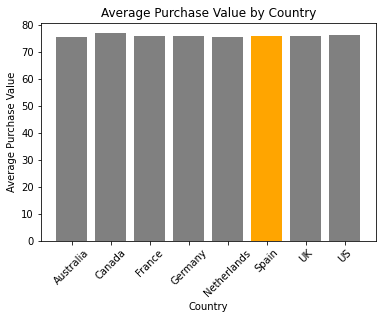

In [77]:
colors = [
    "orange" if country == "Spain" else "gray"
    for country in contry_purchase_avg["country"]
]

plt.figure()

plt.bar(contry_purchase_avg["country"], contry_purchase_avg["purchase_value"], color = colors)

plt.xlabel("Country")
plt.ylabel("Average Purchase Value")
plt.title("Average Purchase Value by Country")

plt.xticks(rotation=45)

plt.show()

In [78]:
#Comparing the average purchase from Spain against the rest of the countries
spain_value = contry_purchase_avg[contry_purchase_avg["country"] == "Spain"]["purchase_value"].values[0]

rest_avg = contry_purchase_avg[contry_purchase_avg["country"] != "Spain"]["purchase_value"].mean()

comparison = pd.DataFrame({
    "group": ["Spain", "Rest"],
    "avg_purchase": [spain_value, rest_avg]
})

print(comparison)

   group  avg_purchase
0  Spain     75.632002
1   Rest     75.869973


Q2. What is the minimum purchase value for customers from Germany?

In [89]:
germany_data = df1_merged[df1_merged["country"] == "Germany"]

germany_min_row = germany_data.loc[
    germany_data["purchase_value"].idxmin()
]

print(germany_min_row[["purchase_value", "product_category"]])

print(f'The minimum purchase value for customers from Germany is {germany_min_row["purchase_value"]} and it correspondes to {germany_min_row["product_category"]} category')

purchase_value         0.39
product_category    fashion
Name: 36870, dtype: object
The minimum purchase value for customers from Germany is 0.39 and it correspondes to fashion category


The minimum purchase value for customers from Germany is of 0.39 and it corresponds to the category of "Fashion". 

Q3. How much did males spend on buying products in the Sports category?

In [90]:
male_sports_spend = df1_merged.loc[
    (df1_merged["gender"] == "Male") &
    (df1_merged["product_category"] == "sports"),
    "purchase_value"
].sum()

print(f'Males spent {male_sports_spend} buying Sports products.')

Males spent 191184.72 buying Sports products.


Q4. What is the average age of female customers from Canada?

In [94]:
print(df1_merged["gender"].unique())

['Other' 'Female' 'Male']


In [111]:
avgfemale_customer_ca = df1_merged.loc[
    (df1_merged["gender"] == "Female") &
    (df1_merged["country"] == "Canada"),
    "age"
].mean()

print(F'The average age of female customer from Canada is {avgfemale_customer_ca}')

The average age of female customer from Canada is 43.06535211267606


In [113]:
#Checking if there is null values to confirm the average obtained is accurate
female_customer_ca = df1_merged.loc[
    (df1_merged["gender"] == "Female") &
    (df1_merged["country"] == "Canada"),
    "age"
]

print(female_customer_ca.isna().sum())

145


An interrogant of thinking this null values could affect the result comes to mind. A small test dropping these null values will be done to confirm if it changes the results.

In [114]:
# Test dropping null values 
female_customer_cat = df1_merged.loc[
    (df1_merged["gender"] == "Female") &
    (df1_merged["country"] == "Canada"),
    "age"
]

print(female_customer_cat)

254      50.0
255      50.0
256      50.0
257      50.0
280      66.0
         ... 
45024    54.0
45119    40.0
45120    40.0
45121    40.0
45122    40.0
Name: age, Length: 1920, dtype: float64


In [115]:
print(female_customer_cat.isna().sum())

145


In [119]:
female_customer_ca_clean = female_customer_cat.dropna()

In [117]:
print(female_customer_ca_clean.isna().sum())

0


In [118]:
average_age = female_customer_ca_clean.mean()
print(average_age)

43.06535211267606


Q5. How much does an average male customer from the UK spend?

In [124]:
male_uk = df1_merged.loc[
    (df1_merged["gender"] == "Male") &
    (df1_merged["country"] == "UK")
]

avg_spent = male_uk["purchase_value"].mean()
print(avg_spent)

76.62530190677967


In [125]:
average_spent_per_customer = male_uk.groupby("customer_id")["purchase_value"].sum().mean()
print(average_spent_per_customer)

343.63080760095016


Q6. What is the maximum purchase value for females in the Toys category?

In [129]:
max_spent_fem_toys = df1_merged.loc[
    (df1_merged["gender"] == "Female") &
    (df1_merged["product_category"] == "toys"),
    "purchase_value"
].max()

print(f'The maximum purchase value for females in Toys category is {max_spent_fem_toys}')

The maximum purchase value for females in Toys category is 423.84


In [128]:
max_row = df1_merged.loc[
    (df1_merged["gender"].str.lower() == "female") &
    (df1_merged["product_category"].str.lower() == "toys") &
    (df1_merged["purchase_value"] == max_spent_fem_toys)
]

print(max_row[["customer_id", "purchase_value", "transaction_id", "product_category"]])

       customer_id  purchase_value  transaction_id product_category
30674         6768          423.84         27282.0             toys


Q7. What is the average number of pages viewed for customers who made a purchase (converted)?

In [146]:
#Exploring the datasets
print(f'"Sessions:" {sessions.columns}')
print(f'"Transactions:" {transactions.columns}')

"Sessions:" Index(['session_id', 'customer_id', 'pages_viewed', 'time_on_site',
       'device_type', 'traffic_source', 'session_date', 'converted'],
      dtype='object')
"Transactions:" Index(['transaction_id', 'customer_id', 'product_category', 'purchase_value',
       'discount_used', 'purchase_date'],
      dtype='object')


Method 1 = Using as a parameter a recorded "transaction_id"

In [147]:
# Merging sessions with transactions datasets
sessions_with_purchase = pd.merge(
    sessions,
    transactions,
    on = "customer_id",
    how = "left"
)

In [148]:
# Keeping only sessions where the customer made a purchase
converted_sessions = sessions_with_purchase.dropna(subset=['transaction_id'])

In [149]:
# Calculating average pages viewed
average_pages_viewed = converted_sessions['pages_viewed'].mean()
print(f'The average of pages viewed for customers who made a purchase is {average_pages_viewed}')

The average of pages viewed for customers who made a purchase is 4.996320345633741


Method 2 = Using the converted attribute of sessions dataset

In [150]:
average_pages_viewed2 = sessions.loc[sessions['converted'] == 1, 'pages_viewed'].mean()
print(f'The average of pages viewed for customer based on the converted attribute is {average_pages_viewed2}')

The average of pages viewed for customer based on the converted attribute is 5.728619675345898


The result should be the same; however, in this case, there is a slight difference, as some sessions marked as converted might not have ended in an actual purchase. Merging the tables ensures that only sessions that resulted in an actual purchase are counted, which gives a slightly lower but more precise average.

Q8. What is the average time spent on the site for purchasing vs non-purchasing customers?

In [157]:
# Identifying purchasing customers
purchasing_customers = transactions["customer_id"].unique()

In [158]:
# Splitting sessions
# Sessions from customers who made a purchase
purchasing_sessions = sessions[
    sessions["customer_id"].isin(purchasing_customers)
]

# Sessions from customers who never purchased
non_purchasing_sessions = sessions[
    ~sessions["customer_id"].isin(purchasing_customers)
]

In [160]:
# Calculating the average

avg_purchasing = purchasing_sessions["time_on_site"].mean()
avg_non_purchasing = non_purchasing_sessions["time_on_site"].mean()

print(f'The average time spent on the site for purchasing customer: {avg_purchasing}')
print(f'The average time spent on the site for non-purchasing customer: {avg_non_purchasing}')


The average time spent on the site for purchasing customer: 300.8760709250551
The average time spent on the site for non-purchasing customer: 294.9563250058515


### Visualisation tasks

Q9. Plot purchasing value across years.

In [165]:
# Converting to datetime
df1_merged["purchase_date"] = pd.to_datetime(df1_merged["purchase_date"])

In [166]:
# Extracting the year
df1_merged["year"] = df1_merged["purchase_date"].dt.year

In [174]:
# Aggregating values per year
purchase_by_year = df1_merged.groupby("year")["purchase_value"].sum()

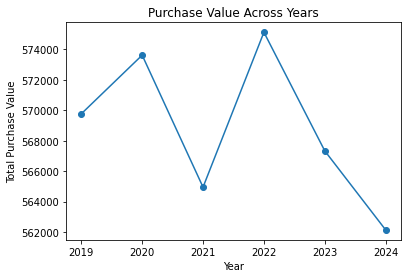

In [178]:
plt.figure()
plt.plot(purchase_by_year.index, purchase_by_year.values, marker="o")

plt.xlabel("Year")
plt.ylabel("Total Purchase Value")
plt.title("Purchase Value Across Years")

plt.show()

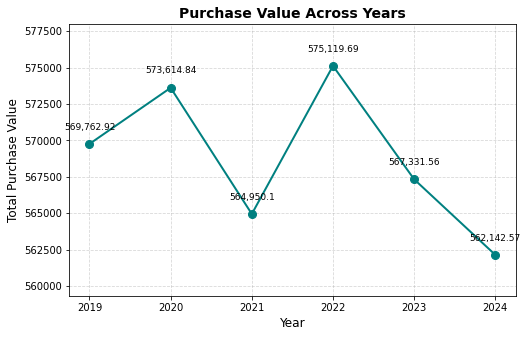

In [190]:
plt.figure(figsize=(8,5))  # Make the figure bigger

# Plot with improvements
plt.plot(
    purchase_by_year.index, 
    purchase_by_year.values, 
    marker="o", 
    markersize=8, 
    linewidth=2, 
    color='teal', 
    linestyle='-'
)

# Add labels for each point
for x, y in zip(purchase_by_year.index, purchase_by_year.values):
    plt.text(x, y + 1000, f"{y:,}", ha='center', fontsize=9)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Purchase Value", fontsize=12)
plt.title("Purchase Value Across Years", fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)  # Add subtle grid
plt.ylim(min(purchase_by_year.values)*0.995, max(purchase_by_year.values)*1.005)  # Adjust y-limits for better visual

plt.show()

Q10. Plot purchasing value across product categories.

In [179]:
# Sum purchase value per product category
purchase_by_category = df1_merged.groupby("product_category")["purchase_value"].sum().sort_values(ascending=False)

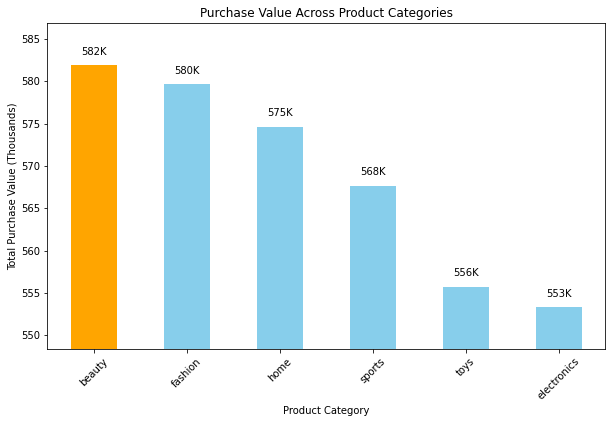

In [188]:
# Scale purchase values to thousands for readability
purchase_by_category_scaled = purchase_by_category / 1000  # in thousands

plt.figure(figsize=(10,6))

# Set bar colors, highlight the top category
colors = ["skyblue"] * len(purchase_by_category_scaled)
top_idx = purchase_by_category_scaled.idxmax()
colors[purchase_by_category_scaled.index.get_loc(top_idx)] = "orange"

# Plot the scaled values
purchase_by_category_scaled.plot(kind="bar", color=colors)

# Add value labels
for i, val in enumerate(purchase_by_category_scaled):
    plt.text(i, val + 1, f"{val:,.0f}K", ha='center', va='bottom', fontsize=10)

# Labels and title
plt.xlabel("Product Category")
plt.ylabel("Total Purchase Value (Thousands)")
plt.title("Purchase Value Across Product Categories")
plt.xticks(rotation=45)

# Zoom y-axis to better show differences
min_val = purchase_by_category_scaled.min()
max_val = purchase_by_category_scaled.max()
plt.ylim(min_val - 5, max_val + 5)  # 5K below min and above max

plt.show()

### Free exercise

Explore the transactions dataset and:

- Create two visualisations of your choice
- Identify three patterns in the data
- Write five insights in plain English explaining what the data tells us

Your insights should focus on behaviour, spending patterns, or conversion